# Task 1 -- EDA and Data Understanding
## License Plate Detection and OCR with YOLO26

---

### Project Overview

| Item | Detail |
|---|---|
| **Project** | License Plate Detection + OCR for Vehicle Identification |
| **Dataset** | Large License Plate Detection Dataset (27,900 images) |
| **Platform** | Kaggle GPU T4 |
| **Model** | Ultralytics YOLO26s |
| **Task** | Task 1 of 4 -- Exploratory Data Analysis |


### Why This Task Matters

Before training any detection model, we must understand the data thoroughly. Skipping EDA leads to poor model design choices -- wrong input resolution, missed annotation errors, and incorrect augmentation strategies. This task documents every finding so Task 2 can make informed training decisions.

---
## Environment Setup and Installation

In [1]:
# Standard library
import os, json, glob, random, warnings
from pathlib import Path
from collections import Counter

# Third-party -- data
import numpy as np
import pandas as pd

# Third-party -- visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Third-party -- image processing
import cv2
from PIL import Image

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

OUTPUT_DIR = Path('/kaggle/working/license_plate_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = Path('/kaggle/input/datasets/fareselmenshawii/large-license-plate-dataset')

# Seed for reproducibility
random.seed(42)
np.random.seed(42)

print(f'Output directory : {OUTPUT_DIR}')
print(f'Dataset directory: {DATASET_DIR}')
print(f'Directory exists : {DATASET_DIR.exists()}')

Output directory : /kaggle/working/license_plate_outputs
Dataset directory: /kaggle/input/datasets/fareselmenshawii/large-license-plate-dataset
Directory exists : True


---
## Load and Verify Dataset Structure

In [2]:
# Explore the dataset directory structure
def explore_directory(path, depth=0, max_depth=3):
    if depth > max_depth:
        return
    items = sorted(path.iterdir()) if path.is_dir() else []
    for item in items:
        prefix = '  ' * depth
        if item.is_dir():
            n_files = len(list(item.rglob('*.*')))
            print(f'{prefix}[DIR] {item.name}/ ({n_files} files)')
            explore_directory(item, depth + 1, max_depth)
        elif depth == max_depth:
            continue
        else:
            print(f'{prefix}{item.name} ({item.stat().st_size / 1024:.1f} KB)')

print('Dataset structure:')
print('=' * 60)
explore_directory(DATASET_DIR, max_depth=2)

Dataset structure:
[DIR] images/ (26929 files)
  [DIR] test/ (386 files)
  [DIR] train/ (25470 files)
  [DIR] val/ (1073 files)
[DIR] labels/ (26931 files)
  [DIR] test/ (386 files)
  [DIR] train/ (25470 files)
  train.cache (6648.8 KB)
  [DIR] val/ (1073 files)
  val.cache (251.8 KB)


---
## Image and Label Census

In [8]:
# Count images and labels per split
splits = ['train', 'val', 'test']
split_stats = {}

for split in splits:
    img_dir = DATASET_DIR / split / 'images'
    lbl_dir = DATASET_DIR / split / 'labels'
    
    if not img_dir.exists():
        # Try alternate structure
        for alt in [DATASET_DIR / split, DATASET_DIR / 'images' / split]:
            if alt.exists():
                img_dir = alt
                break
    
    if not lbl_dir.exists():
        for alt in [DATASET_DIR / split, DATASET_DIR / 'labels' / split]:
            if alt.exists():
                lbl_dir = alt
                break
    
    img_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp']
    images = []
    for ext in img_extensions:
        images.extend(list(img_dir.glob(ext)))
    
    labels = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
    
    # Check for matching pairs
    img_stems = {p.stem for p in images}
    lbl_stems = {p.stem for p in labels}
    matched = img_stems & lbl_stems
    imgs_without_labels = img_stems - lbl_stems
    labels_without_imgs = lbl_stems - img_stems
    
    split_stats[split] = {
        'images': len(images),
        'labels': len(labels),
        'matched': len(matched),
        'imgs_no_label': len(imgs_without_labels),
        'labels_no_img': len(labels_without_imgs),
        'img_dir': str(img_dir),
        'lbl_dir': str(lbl_dir)
    }
    
    print(f'{split.upper():>8} : {len(images):>6,} images | {len(labels):>6,} labels | '
          f'{len(matched):>6,} matched | {len(imgs_without_labels)} orphan images | '
          f'{len(labels_without_imgs)} orphan labels')

total_images = sum(s['images'] for s in split_stats.values())
total_labels = sum(s['labels'] for s in split_stats.values())
print(f'{"TOTAL":>8} : {total_images:>6,} images | {total_labels:>6,} labels')

   TRAIN : 25,470 images | 25,470 labels | 25,470 matched | 0 orphan images | 0 orphan labels
     VAL :  1,073 images |  1,073 labels |  1,073 matched | 0 orphan images | 0 orphan labels
    TEST :    386 images |    386 labels |    386 matched | 0 orphan images | 0 orphan labels
   TOTAL : 26,929 images | 26,929 labels


---
## Sample Images with Annotations Overlaid

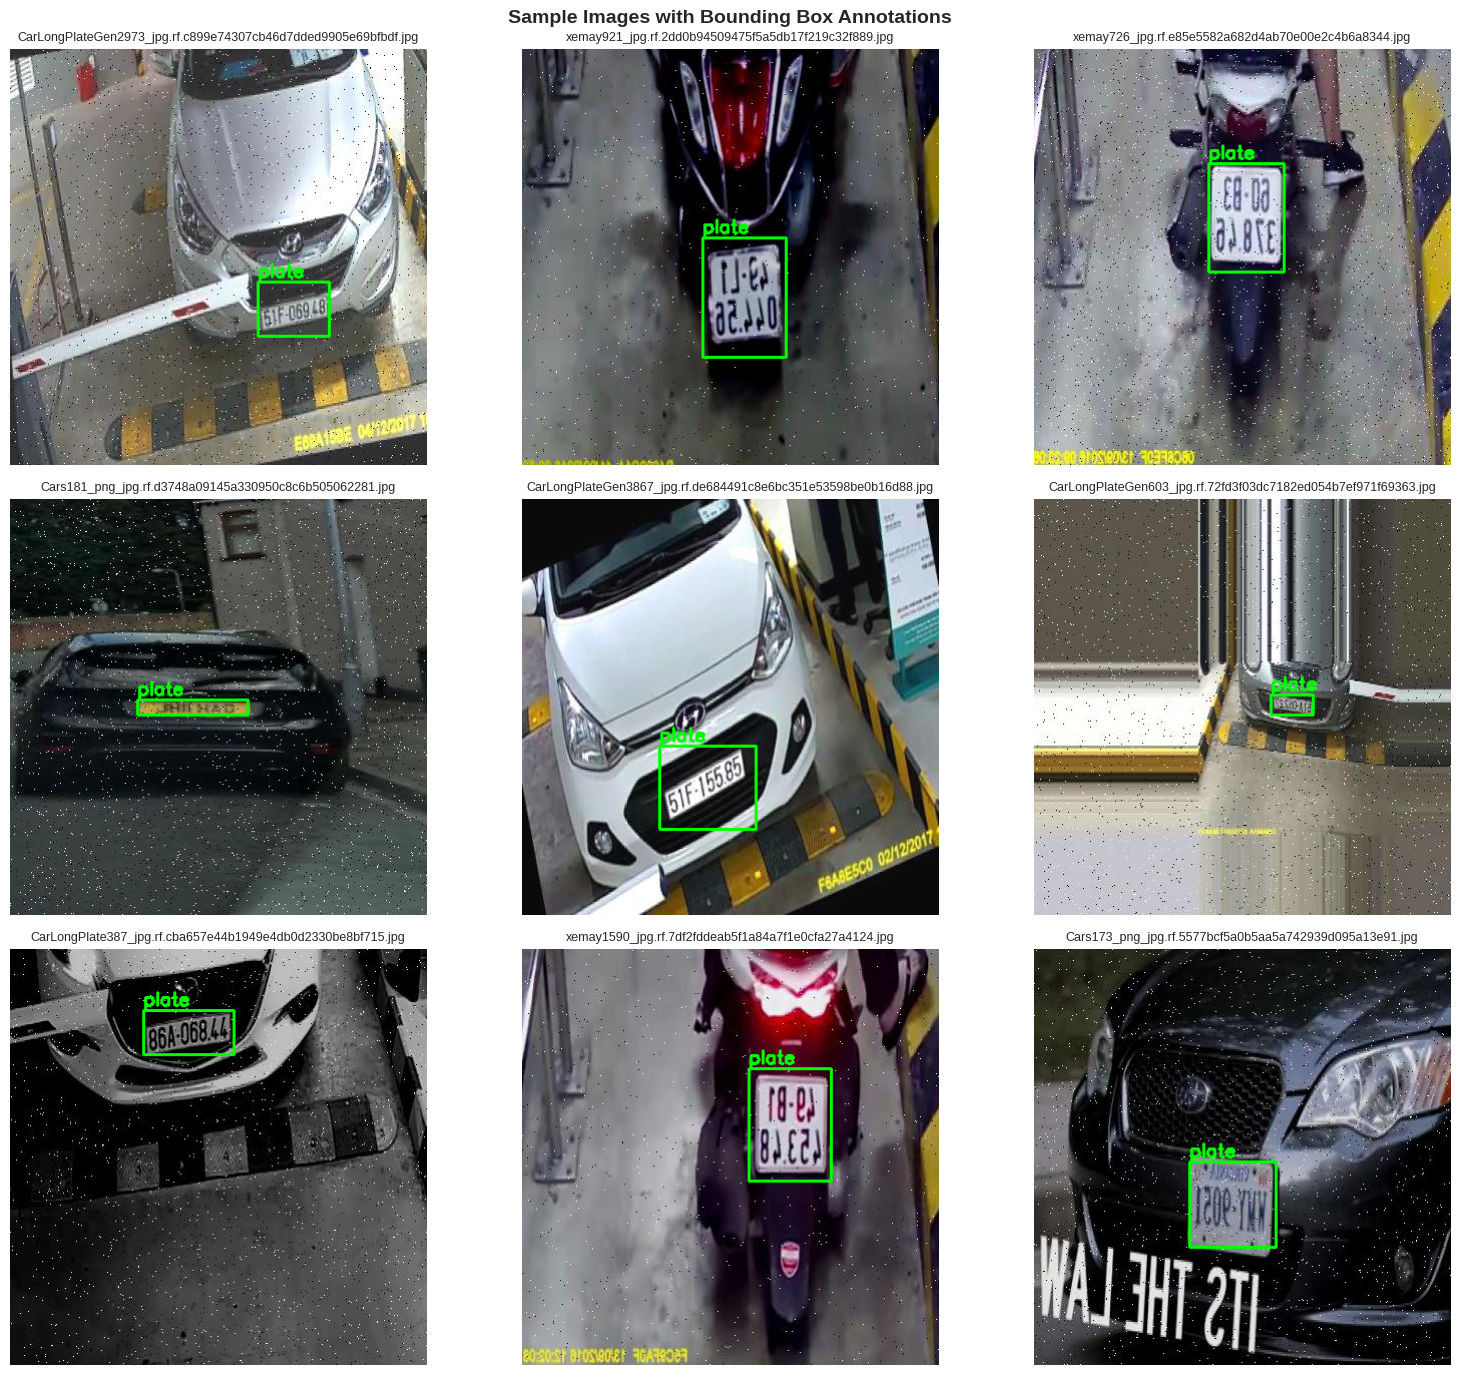

Saved: sample_annotations.png


In [14]:
# Display sample images with bounding boxes
def draw_yolo_boxes(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]
        for line in lines:
            parts = line.split()
            if len(parts) >= 5:
                xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, 'plate', (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return img

# Sample 9 random images
sample_imgs = random.sample(all_train_images, min(9, len(all_train_images)))

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for idx, (ax, img_path) in enumerate(zip(axes.flat, sample_imgs)):
    lbl_path = Path(str(img_path).replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt')
    img = draw_yolo_boxes(img_path, lbl_path)
    ax.imshow(img)
    ax.set_title(f'{img_path.name}', fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Images with Bounding Box Annotations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_annotations.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: sample_annotations.png')

---
## Data Quality Summary and Cleaning Plan

### Consolidating findings into actionable decisions

This step synthesizes all observations into a structured cleaning plan that Task 2 will execute. Rather than making ad-hoc decisions during training, we document every data quality issue and its resolution here, making the pipeline auditable and reproducible.

In [16]:
# Compile all statistics
dataset_summary = {
    'total_images': total_images,
    'total_labels': total_labels,
    'splits': split_stats,
    'image_properties': img_stats,
    'bbox_stats': {
        'total_boxes_sampled': len(box_widths),
        'boxes_per_image_mean': float(np.mean(boxes_per_image)),
        'boxes_per_image_max': int(max(boxes_per_image)),
        'plate_width_mean': float(np.mean(box_widths)),
        'plate_height_mean': float(np.mean(box_heights)),
        'plate_area_pct_mean': float(np.mean(area_pct)),
        'plate_area_pct_median': float(np.median(area_pct)),
        'small_plates_pct': float(sum(1 for a in area_pct if a < 1) / len(area_pct) * 100),
        'plate_aspect_ratio_mean': float(np.mean(plate_aspects)),
        'unique_classes': sorted(set(class_ids))
    },
    'quality': {
        'dark_images_pct': float(dark_imgs / len(brightness_values) * 100) if brightness_values else 0,
        'blurry_images_pct': float(blurry_imgs / len(blur_scores) * 100) if blur_scores else 0
    }
}

# Save summary
with open(OUTPUT_DIR / 'dataset_summary.json', 'w') as f:
    json.dump(dataset_summary, f, indent=2)
print(f'Saved: dataset_summary.json ({(OUTPUT_DIR / "dataset_summary.json").stat().st_size / 1024:.1f} KB)')

# Print cleaning plan
print()
print('DATA QUALITY SUMMARY')
print('=' * 60)
print(f'Total images       : {total_images:,}')
print(f'Total labels       : {total_labels:,}')
print(f'Mean plates/image  : {np.mean(boxes_per_image):.2f}')
print(f'Mean plate area    : {np.mean(area_pct):.2f}% of image')
print(f'Small plates (<1%) : {sum(1 for a in area_pct if a < 1)/len(area_pct)*100:.1f}%')
print()
print('CLEANING PLAN FOR TASK 2')
print('=' * 60)
print('1. Verify data.yaml class mapping matches annotations')
print('2. Use imgsz=640 if mean plate area > 1%, else consider 1280')
print('3. Enable mosaic augmentation for varied plate positions')
print('4. Add brightness jitter if dark images > 10%')
print('5. No horizontal flip augmentation (plates are not symmetric)')
print('6. Use YOLO26s as primary model (best speed-accuracy for T4)')

Saved: dataset_summary.json (2.1 KB)

DATA QUALITY SUMMARY
Total images       : 26,929
Total labels       : 26,929
Mean plates/image  : 1.11
Mean plate area    : 2.86% of image
Small plates (<1%) : 36.5%

CLEANING PLAN FOR TASK 2
1. Verify data.yaml class mapping matches annotations
2. Use imgsz=640 if mean plate area > 1%, else consider 1280
3. Enable mosaic augmentation for varied plate positions
4. Add brightness jitter if dark images > 10%
5. No horizontal flip augmentation (plates are not symmetric)
6. Use YOLO26s as primary model (best speed-accuracy for T4)
